In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error

In [2]:
housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_train_error = mean_squared_error(y_train, lr.predict(X_train_scaled))
lr_test_error = mean_squared_error(y_test, lr.predict(X_test_scaled))

print("Linear Regression Train Error:", lr_train_error)
print("Linear Regression Test Error:", lr_test_error)

Linear Regression Train Error: 0.5233576288267755
Linear Regression Test Error: 0.5305677824766754


In [6]:
alphas = np.logspace(-3, 2, 10)

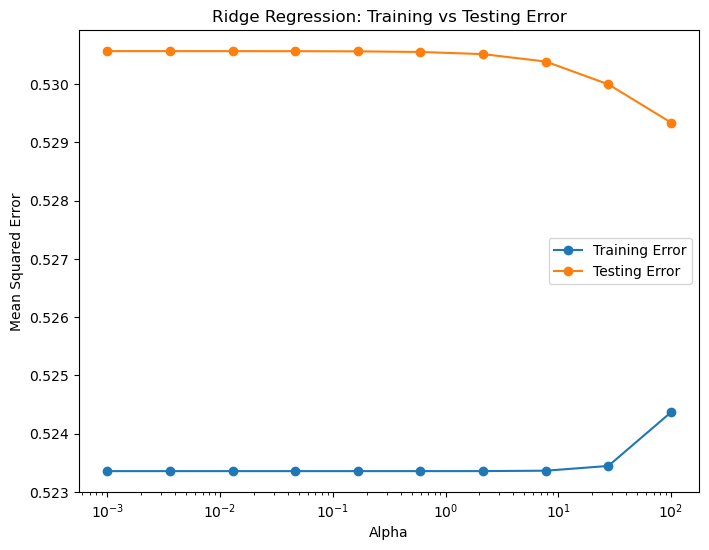

In [7]:
ridge_train_errors = []
ridge_test_errors = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)

    ridge_train_errors.append(
        mean_squared_error(y_train, ridge.predict(X_train_scaled))
    )
    ridge_test_errors.append(
        mean_squared_error(y_test, ridge.predict(X_test_scaled))
    )

plt.figure(figsize=(8, 6))
plt.plot(alphas, ridge_train_errors, marker='o', label='Training Error')
plt.plot(alphas, ridge_test_errors, marker='o', label='Testing Error')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('Ridge Regression: Training vs Testing Error')
plt.legend()
plt.show()



# Ridge Regression - Training vs Testing Error

**What we observe from the plot**
- Training error stays low and almost constant across α values
- Testing error slightly decreases as α increases
- No sharp rise in error even for large α

**Interpretation**
Ridge regression applies an L2 penalty which shrinks coefficients smoothly without removing any feature. As α increases the model becomes slightly less flexible reducing overfitting while still retaining all features. This explains why the test error improves marginally and remains stable instead of increasing sharply.

**Conclusion**
Ridge regression improves generalization by controlling coefficient magnitude not by removing features.

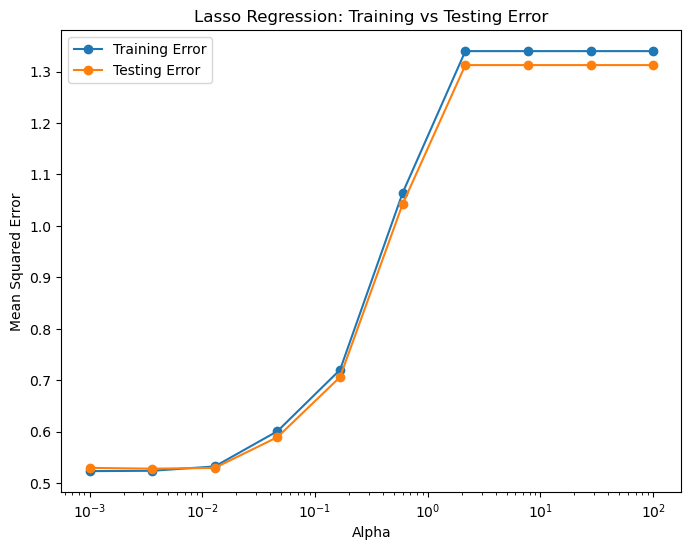

In [8]:
lasso_train_errors = []
lasso_test_errors = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=5000)
    lasso.fit(X_train_scaled, y_train)

    lasso_train_errors.append(
        mean_squared_error(y_train, lasso.predict(X_train_scaled))
    )
    lasso_test_errors.append(
        mean_squared_error(y_test, lasso.predict(X_test_scaled))
    )

plt.figure(figsize=(8, 6))
plt.plot(alphas, lasso_train_errors, marker='o', label='Training Error')
plt.plot(alphas, lasso_test_errors, marker='o', label='Testing Error')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('Lasso Regression: Training vs Testing Error')
plt.legend()
plt.show()



# Lasso Regression – Training vs Testing Error
**What we observe from the plot**
- For very small α, training and testing errors are low
- As α increases, both errors rise sharply
- Training and testing curves increase almost together

**Interpretation**
Lasso applies an L1 penalty which forces some coefficients to become exactly zero. When α becomes large too many features are eliminated causing the model to lose important information. This leads to underfitting which is reflected by the rapid increase in both training and testing error.

**Conclusion**
Lasso performs feature selection but excessive regularization can remove useful features and degrade performance.

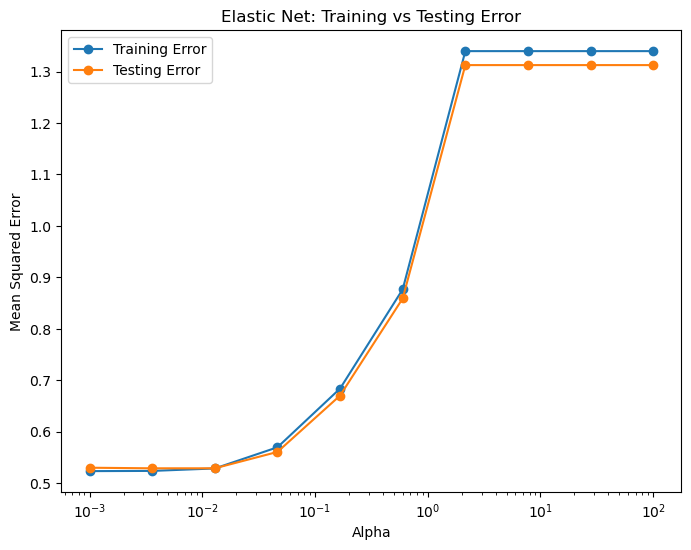

In [9]:
elastic_train_errors = []
elastic_test_errors = []

for alpha in alphas:
    elastic = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=5000)
    elastic.fit(X_train_scaled, y_train)

    elastic_train_errors.append(
        mean_squared_error(y_train, elastic.predict(X_train_scaled))
    )
    elastic_test_errors.append(
        mean_squared_error(y_test, elastic.predict(X_test_scaled))
    )

plt.figure(figsize=(8, 6))
plt.plot(alphas, elastic_train_errors, marker='o', label='Training Error')
plt.plot(alphas, elastic_test_errors, marker='o', label='Testing Error')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('Elastic Net: Training vs Testing Error')
plt.legend()
plt.show()

# Elastic Net – Training vs Testing Error
**What we observe from the plot**
- Error behavior is between Ridge and Lasso
- Training and testing error increase with α
- Increase is smoother than Lasso but steeper than Ridge

**Interpretation**
Elastic Net combines L1 and L2 penalties. It both shrinks coefficients and removes some features. As α increases the combined penalty becomes strong reducing model flexibility. This causes underfitting at high α values but the transition is more balanced compared to Lasso.

**Conclusion**
Elastic Net provides a compromise between Ridge and Lasso offering controlled shrinkage and limited feature elimination.

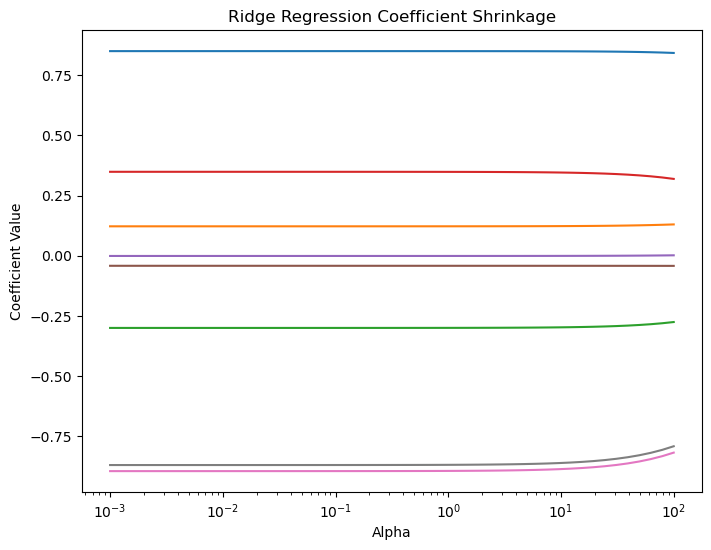

In [10]:
alphas_path = np.logspace(-3, 2, 50)
ridge_coefs = []

for alpha in alphas_path:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)

ridge_coefs = np.array(ridge_coefs)

plt.figure(figsize=(8, 6))
for i in range(ridge_coefs.shape[1]):
    plt.plot(alphas_path, ridge_coefs[:, i])

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression Coefficient Shrinkage')
plt.show()


# Coefficient Shrinkage – Ridge Regression
**What the plot shows**
- All coefficient curves shrink gradually
- No coefficient becomes exactly zero
- Coefficients remain non-zero even for large α

**Interpretation**
The L2 penalty discourages large weights but does not eliminate features. This confirms that Ridge keeps all features while reducing their influence.

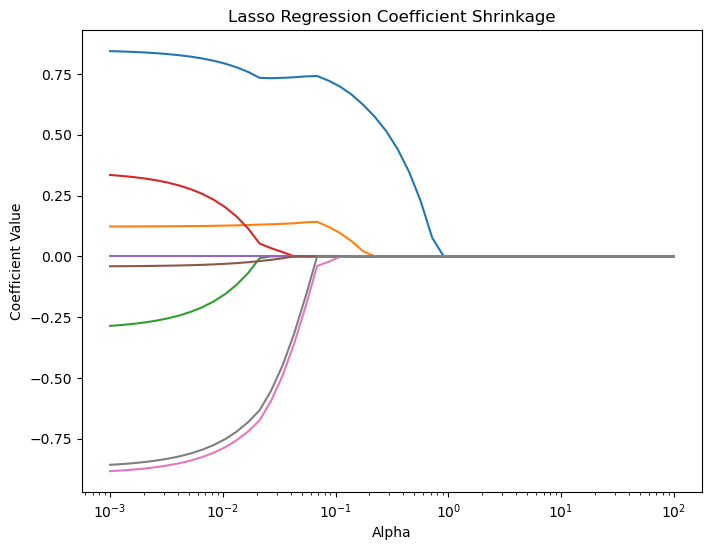

In [11]:
lasso_coefs = []

for alpha in alphas_path:
    lasso = Lasso(alpha=alpha, max_iter=5000)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso.coef_)

lasso_coefs = np.array(lasso_coefs)

plt.figure(figsize=(8, 6))
for i in range(lasso_coefs.shape[1]):
    plt.plot(alphas_path, lasso_coefs[:, i])

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regression Coefficient Shrinkage')
plt.show()

# Coefficient Shrinkage – Lasso Regression
**What the plot shows**
- Several coefficients drop to exactly zero
- Once zero, they remain zero as α increases
- Only a few features survive at higher α

**Interpretation**
The L1 penalty forces sparsity by eliminating less important features. This visually demonstrates automatic feature selection.

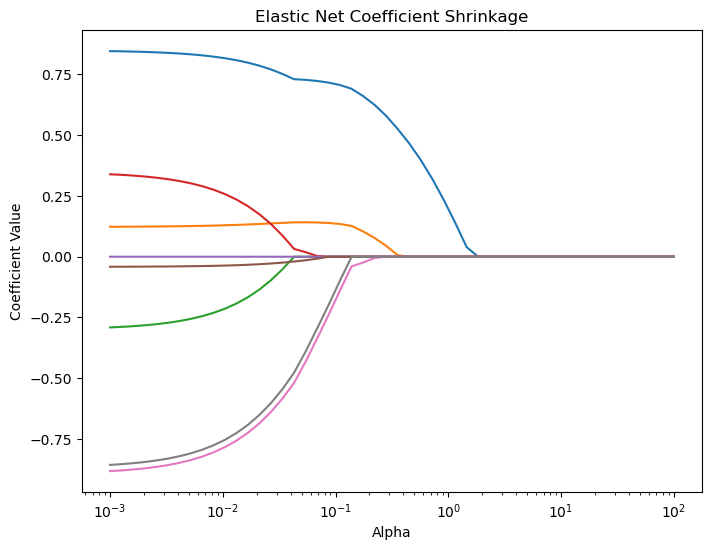

In [12]:
elastic_coefs = []

for alpha in alphas_path:
    elastic = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=5000)
    elastic.fit(X_train_scaled, y_train)
    elastic_coefs.append(elastic.coef_)

elastic_coefs = np.array(elastic_coefs)

plt.figure(figsize=(8, 6))
for i in range(elastic_coefs.shape[1]):
    plt.plot(alphas_path, elastic_coefs[:, i])

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Elastic Net Coefficient Shrinkage')
plt.show()

## Coefficient Shrinkage – Elastic Net
**What the plot shows**
- Some coefficients shrink smoothly
- Some coefficients go to zero
- Behavior lies between Ridge and Lasso

**Interpretation**
Elastic Net combines both penalties so it shrinks coefficients like Ridge and removes features like Lasso. This balanced behavior is especially useful when features are correlated.

In [13]:
best_ridge_mse = min(ridge_test_errors)
best_ridge_alpha = alphas[np.argmin(ridge_test_errors)]


In [14]:
best_lasso_mse = min(lasso_test_errors)
best_lasso_alpha = alphas[np.argmin(lasso_test_errors)]


In [15]:
best_elastic_mse = min(elastic_test_errors)
best_elastic_alpha = alphas[np.argmin(elastic_test_errors)]


In [16]:
print("Best Ridge Test MSE:", best_ridge_mse, "at alpha =", best_ridge_alpha)
print("Best Lasso Test MSE:", best_lasso_mse, "at alpha =", best_lasso_alpha)
print("Best Elastic Net Test MSE:", best_elastic_mse, "at alpha =", best_elastic_alpha)


Best Ridge Test MSE: 0.5293421621695781 at alpha = 100.0
Best Lasso Test MSE: 0.5281563936458936 at alpha = 0.003593813663804626
Best Elastic Net Test MSE: 0.5288631830030267 at alpha = 0.003593813663804626


**The best-performing model was Lasso Regression as it achieved the lowest test mean squared error among all regularized models after tuning the regularization parameter. This confirms that Lasso provided the best generalization performance on the dataset.**

# Analysis & Hypothesis

# Why does regularization improve test performance?

From the training vs testing error plots we observe that models without sufficient regularization tend to overfit the training data. Regularization improves test performance by penalizing large coefficient values which prevents the model from becoming overly sensitive to noise in the training data.

As the regularization strength (α) increases from very small values the test error initially decreases indicating improved generalization. This shows that regularization helps the model focus on the true underlying signal rather than fitting random fluctuations in the data.

# Why does Ridge keep all features but shrink them?

The Ridge regression plots show that all coefficients decrease smoothly as α increases but none of them become exactly zero. This behavior is also reflected in the coefficient shrinkage plot where every feature remains present across all values of α.

This happens because Ridge uses an L2 penalty which discourages large weights by squaring them. Squaring the coefficients makes large values costly but it does not force coefficients to become zero. As a result Ridge keeps all features while reducing their influence leading to a more stable and less overfitted model.

# Why does Lasso remove features entirely?

In the Lasso regression coefficient shrinkage plot several coefficients are driven exactly to zero as α increases. At the same time the training and testing error plots show that for larger α values both errors increase sharply.

This occurs because Lasso uses an L1 penalty which encourages sparsity. The absolute-value penalty makes it optimal for some coefficients to become exactly zero effectively removing those features from the model. While this performs automatic feature selection excessive regularization can remove important features and lead to underfitting.

# Why does Elastic Net behave differently from both?

Elastic Net combines both L1 and L2 penalties which is clearly visible in its coefficient shrinkage plot. Some coefficients shrink smoothly like Ridge while others are pushed to zero like Lasso.

In the training vs testing error plot Elastic Net shows behavior that lies between Ridge and Lasso. The test error increases more gradually than Lasso but more sharply than Ridge. This balanced behavior allows Elastic Net to handle correlated features better than Lasso while still performing feature selection unlike Ridge.

# Which model performed best on your dataset and why?

Lasso Regression performed best on the dataset because it achieved the lowest test mean squared error (MSE) after tuning the regularization parameter. Specifically Lasso achieved a test MSE of 0.5281 which is lower than Ridge, Elastic Net, and standard Linear Regression.

This result indicates that Lasso generalized slightly better to unseen data. The coefficient shrinkage plots further support this conclusion by showing that Lasso eliminated less important features by driving some coefficients exactly to zero. This feature selection reduced model complexity and helped prevent overfitting leading to improved test performance compared to the other models.